# Probability & Statistics for Machine Learning

## Why Statistics?

Real data is **noisy** and **uncertain**. Statistics helps you:
- Describe data (mean, variance)
- Understand distributions (what's normal?)
- Make predictions under uncertainty
- Update beliefs with new evidence (Bayes)

### The Big Picture

| Concept | Think of it as | Used in |
|---------|---------------|----------|
| Mean | Center of data | Average prediction |
| Variance | How spread out | Model confidence |
| Distribution | Shape of data | Generating samples |
| Bayes' Theorem | Update beliefs | Spam filters, diagnosis |
| Correlation | How two things relate | Feature selection |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

---
## 1. Mean, Median, Mode (Central Tendency)

Three ways to find the "center" of your data:

- **Mean** = average = sum / count (sensitive to outliers)
- **Median** = middle value when sorted (robust to outliers)
- **Mode** = most frequent value

### Why it matters: ML models often predict the mean.

In [2]:
normal_data = np.array([50, 52, 48, 51, 49, 50, 53, 47, 50, 51])
with_outlier = np.append(normal_data, [200])

print("=== Normal Data ===")
print(f"Data: {normal_data}")
print(f"Mean:   {np.mean(normal_data):.1f}")
print(f"Median: {np.median(normal_data):.1f}")

print("\n=== With Outlier (200) ===")
print(f"Data: {with_outlier}")
print(f"Mean:   {np.mean(with_outlier):.1f}  ← shifted by outlier!")
print(f"Median: {np.median(with_outlier):.1f}  ← barely changed")

print("\nKey insight: Median is robust to outliers.")
print("When data has extreme values, median is more representative.")

=== Normal Data ===
Data: [50 52 48 51 49 50 53 47 50 51]
Mean:   50.1
Median: 50.0

=== With Outlier (200) ===
Data: [ 50  52  48  51  49  50  53  47  50  51 200]
Mean:   63.7  ← shifted by outlier!
Median: 50.0  ← barely changed

Key insight: Median is robust to outliers.
When data has extreme values, median is more representative.


---
## 2. Variance & Standard Deviation (How Spread Out)

- **Variance** = average squared distance from mean
- **Standard Deviation (std)** = sqrt(variance) = same units as data

### Intuition:
- Low std = data clustered tightly around mean
- High std = data spread out widely

### In ML:
- Low variance model = stable predictions
- High variance model = predictions change a lot with different data (overfitting)

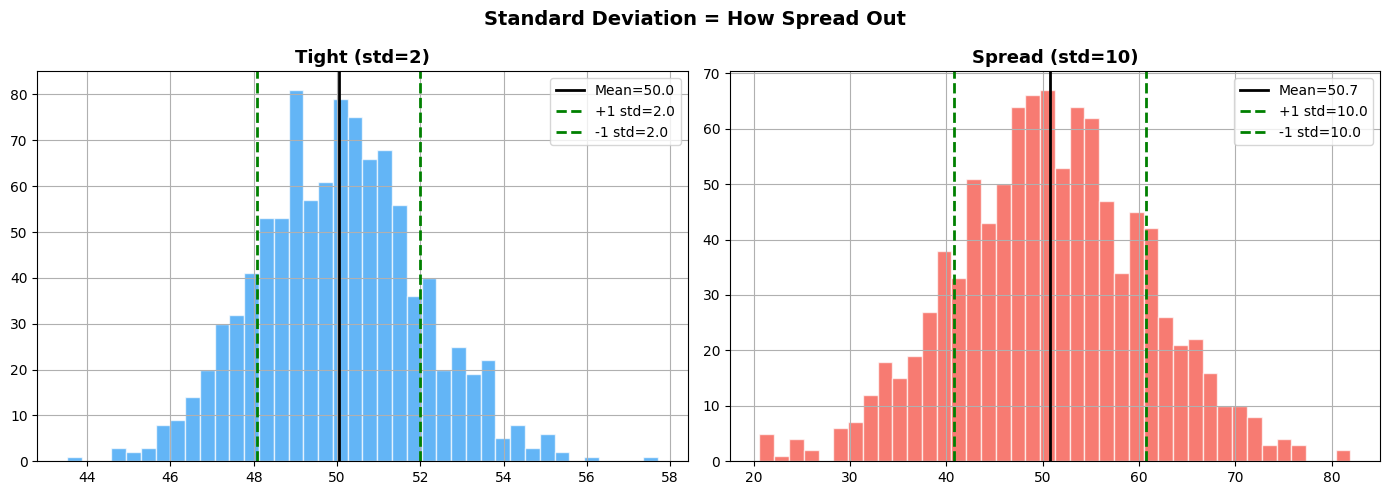

Tight: mean=50.0, std=2.0
Spread: mean=50.7, std=10.0
Same mean, VERY different spread!


In [3]:
np.random.seed(42)

tight = np.random.normal(50, 2, 1000)
spread = np.random.normal(50, 10, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, name, color in zip(axes, [tight, spread],
    ['Tight (std=2)', 'Spread (std=10)'], ['#2196F3', '#F44336']):
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(data), color='black', linewidth=2, label=f'Mean={np.mean(data):.1f}')
    ax.axvline(np.mean(data) + np.std(data), color='green', linewidth=2, linestyle='--',
               label=f'+1 std={np.std(data):.1f}')
    ax.axvline(np.mean(data) - np.std(data), color='green', linewidth=2, linestyle='--',
               label=f'-1 std={np.std(data):.1f}')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

plt.suptitle('Standard Deviation = How Spread Out', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Tight: mean={np.mean(tight):.1f}, std={np.std(tight):.1f}")
print(f"Spread: mean={np.mean(spread):.1f}, std={np.std(spread):.1f}")
print("Same mean, VERY different spread!")

---
## 3. The Normal Distribution (Bell Curve)

The most important distribution in statistics.

### Properties:
- Symmetric around the mean
- 68% of data within ±1 std
- 95% of data within ±2 std
- 99.7% of data within ±3 std

### Why it matters:
- Many natural phenomena are normally distributed
- Central Limit Theorem: averages tend toward normal
- Many ML algorithms assume normal distribution

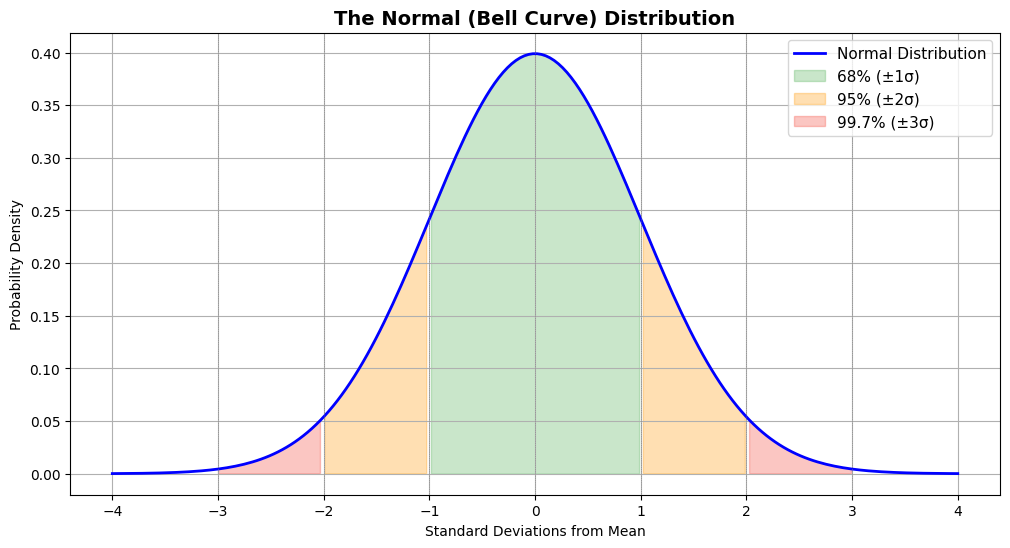

The 68-95-99.7 Rule:
  68% of data is within 1 standard deviation of mean
  95% of data is within 2 standard deviations
  99.7% of data is within 3 standard deviations


In [4]:
from scipy import stats

x = np.linspace(-4, 4, 200)
y = stats.norm.pdf(x, 0, 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, y, 'b-', linewidth=2, label='Normal Distribution')
ax.fill_between(x, y, where=(x >= -1) & (x <= 1), alpha=0.3, color='#4CAF50', label='68% (±1σ)')
ax.fill_between(x, y, where=((x >= -2) & (x < -1)) | ((x > 1) & (x <= 2)),
                alpha=0.3, color='#FF9800', label='95% (±2σ)')
ax.fill_between(x, y, where=((x >= -3) & (x < -2)) | ((x > 2) & (x <= 3)),
                alpha=0.3, color='#F44336', label='99.7% (±3σ)')

for i in range(-3, 4):
    ax.axvline(i, color='gray', linewidth=0.5, linestyle=':')

ax.set_title('The Normal (Bell Curve) Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlabel('Standard Deviations from Mean')
ax.set_ylabel('Probability Density')
plt.show()

print("The 68-95-99.7 Rule:")
print("  68% of data is within 1 standard deviation of mean")
print("  95% of data is within 2 standard deviations")
print("  99.7% of data is within 3 standard deviations")

---
## 4. Correlation (How Two Variables Relate)

### Correlation coefficient (r): -1 to +1
- **r = +1**: perfect positive (both go up together)
- **r = 0**: no relationship
- **r = -1**: perfect negative (one goes up, other goes down)

### ⚠️ Correlation ≠ Causation!
Just because two things are correlated doesn't mean one causes the other.

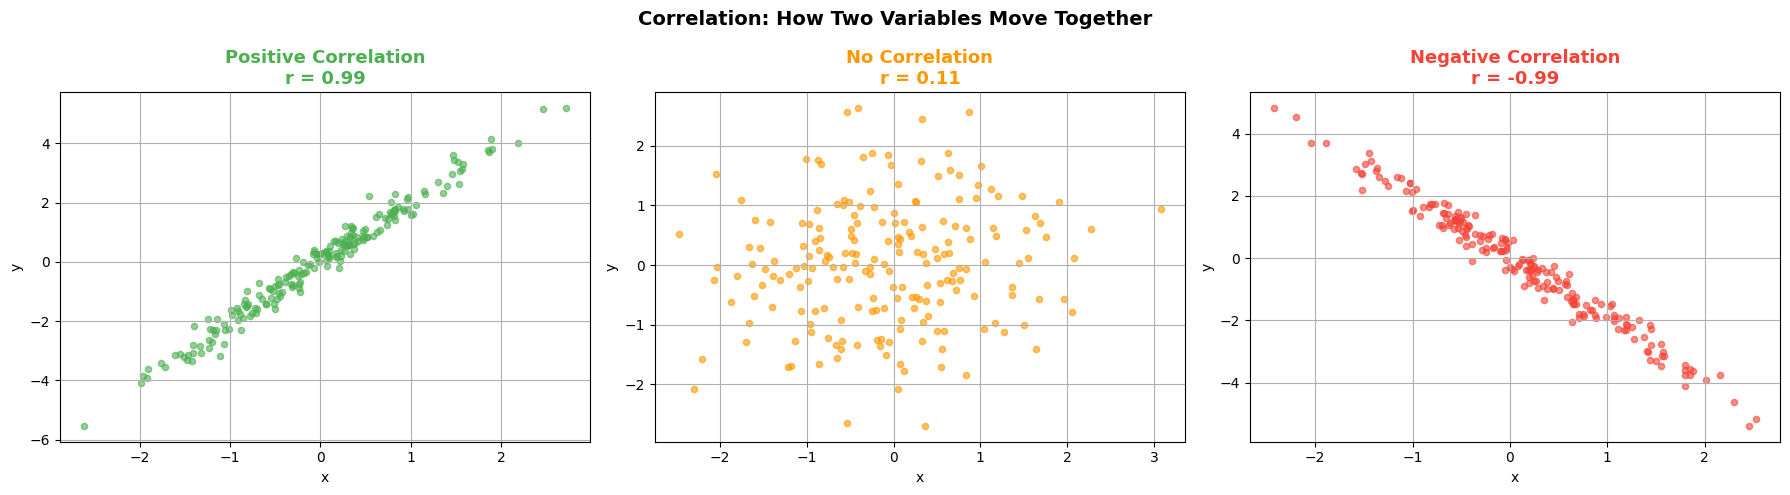

In [5]:
np.random.seed(42)
n = 200

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x1 = np.random.randn(n)
y1 = x1 * 2 + np.random.randn(n) * 0.3
r1 = np.corrcoef(x1, y1)[0, 1]
axes[0].scatter(x1, y1, alpha=0.6, s=20, c='#4CAF50')
axes[0].set_title(f'Positive Correlation\nr = {r1:.2f}', fontsize=13, fontweight='bold', color='#4CAF50')

x2 = np.random.randn(n)
y2 = np.random.randn(n)
r2 = np.corrcoef(x2, y2)[0, 1]
axes[1].scatter(x2, y2, alpha=0.6, s=20, c='#FF9800')
axes[1].set_title(f'No Correlation\nr = {r2:.2f}', fontsize=13, fontweight='bold', color='#FF9800')

x3 = np.random.randn(n)
y3 = -x3 * 2 + np.random.randn(n) * 0.3
r3 = np.corrcoef(x3, y3)[0, 1]
axes[2].scatter(x3, y3, alpha=0.6, s=20, c='#F44336')
axes[2].set_title(f'Negative Correlation\nr = {r3:.2f}', fontsize=13, fontweight='bold', color='#F44336')

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Correlation: How Two Variables Move Together', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Covariance Matrix (Multi-Variable Relationships)

For multiple features, the **covariance matrix** shows how every pair relates.

- Diagonal = variance of each feature
- Off-diagonal = how two features covary

This is a direct application of **linear algebra** (symmetric matrix)!

In [6]:
np.random.seed(42)

height = np.random.normal(170, 10, 100)
weight = height * 0.6 + np.random.normal(20, 5, 100)
age = np.random.normal(35, 8, 100)

data = np.column_stack([height, weight, age])

cov_matrix = np.cov(data.T)
corr_matrix = np.corrcoef(data.T)

print("=== Covariance Matrix ===")
print(f"{'':>8} {'Height':>10} {'Weight':>10} {'Age':>10}")
for i, name in enumerate(['Height', 'Weight', 'Age']):
    print(f"{name:>8} {cov_matrix[i,0]:>10.2f} {cov_matrix[i,1]:>10.2f} {cov_matrix[i,2]:>10.2f}")

print(f"\n=== Correlation Matrix ===")
print(f"{'':>8} {'Height':>10} {'Weight':>10} {'Age':>10}")
for i, name in enumerate(['Height', 'Weight', 'Age']):
    print(f"{name:>8} {corr_matrix[i,0]:>10.2f} {corr_matrix[i,1]:>10.2f} {corr_matrix[i,2]:>10.2f}")

print(f"\nHeight-Weight correlation: {corr_matrix[0,1]:.2f} (strong!)")
print(f"Height-Age correlation:    {corr_matrix[0,2]:.2f} (weak)")
print("Taller people tend to weigh more. Age unrelated to height.")

=== Covariance Matrix ===
             Height     Weight        Age
  Height      82.48      43.58      15.03
  Weight      43.58      45.34       7.51
     Age      15.03       7.51      75.24

=== Correlation Matrix ===
             Height     Weight        Age
  Height       1.00       0.71       0.19
  Weight       0.71       1.00       0.13
     Age       0.19       0.13       1.00

Height-Weight correlation: 0.71 (strong!)
Height-Age correlation:    0.19 (weak)
Taller people tend to weigh more. Age unrelated to height.


---
## 6. Bayes' Theorem (Update Your Beliefs)

### The most practical formula in probability:

```
P(A|B) = P(B|A) * P(A) / P(B)
```

### In plain English:
- **P(A)** = your initial belief (prior)
- **P(B|A)** = how likely is the evidence if A is true (likelihood)
- **P(A|B)** = your updated belief after seeing evidence (posterior)

### Example: Medical Test
- 1% of people have a disease (prior)
- Test is 90% accurate when disease present (sensitivity)
- Test is 5% false positive (specificity issue)
- You test positive. What's the chance you actually have it?

In [7]:
p_disease = 0.01
p_positive_given_disease = 0.90
p_positive_given_healthy = 0.05

p_healthy = 1 - p_disease
p_positive = (p_positive_given_disease * p_disease +
              p_positive_given_healthy * p_healthy)

p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print("=== Bayes' Theorem: Medical Test ===")
print(f"P(disease)         = {p_disease:.2f}  (1% of people have it)")
print(f"P(+|disease)       = {p_positive_given_disease:.2f}  (90% accurate)")
print(f"P(+|healthy)       = {p_positive_given_healthy:.2f}  (5% false positive)")
print(f"P(positive)        = {p_positive:.4f}")
print(f"\nP(disease|+)       = {p_disease_given_positive:.4f} = {p_disease_given_positive*100:.1f}%")
print()
print(f"SURPRISE: Even with a positive test, only {p_disease_given_positive*100:.1f}% chance!")
print("Why? Because the disease is rare (1%), false positives add up.")
print("This is why doctors don't panic at one positive test.")
print()
print("Bayes' Theorem = updating your belief with new evidence.")
print("Used in: spam filters, medical diagnosis, recommendation systems")

=== Bayes' Theorem: Medical Test ===
P(disease)         = 0.01  (1% of people have it)
P(+|disease)       = 0.90  (90% accurate)
P(+|healthy)       = 0.05  (5% false positive)
P(positive)        = 0.0585

P(disease|+)       = 0.1538 = 15.4%

SURPRISE: Even with a positive test, only 15.4% chance!
Why? Because the disease is rare (1%), false positives add up.
This is why doctors don't panic at one positive test.

Bayes' Theorem = updating your belief with new evidence.
Used in: spam filters, medical diagnosis, recommendation systems


---
## 7. Random Variables & Sampling

### Random Variable = a quantity whose value depends on chance

### Common distributions:
- **Uniform**: all values equally likely (dice roll)
- **Normal**: bell curve (heights, errors)
- **Binomial**: number of successes in n tries (coin flips)
- **Poisson**: number of events in a time period (emails per hour)

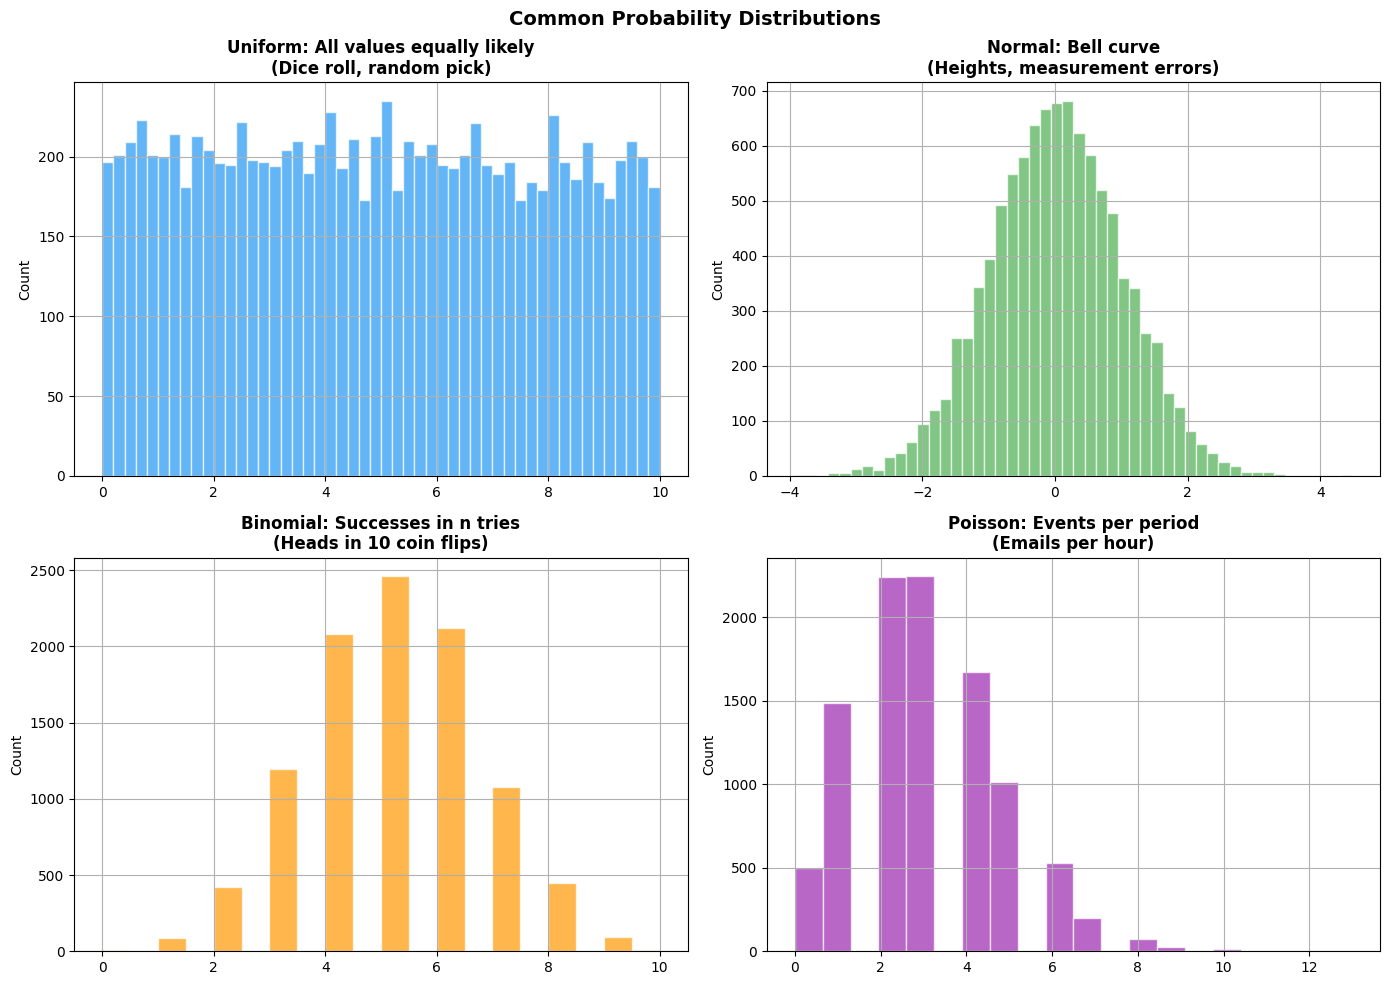

In [8]:
np.random.seed(42)
n = 10000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

uniform = np.random.uniform(0, 10, n)
axes[0,0].hist(uniform, bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0,0].set_title('Uniform: All values equally likely\n(Dice roll, random pick)', fontsize=12, fontweight='bold')

normal = np.random.normal(0, 1, n)
axes[0,1].hist(normal, bins=50, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[0,1].set_title('Normal: Bell curve\n(Heights, measurement errors)', fontsize=12, fontweight='bold')

binomial = np.random.binomial(10, 0.5, n)
axes[1,0].hist(binomial, bins=20, color='#FF9800', alpha=0.7, edgecolor='white')
axes[1,0].set_title('Binomial: Successes in n tries\n(Heads in 10 coin flips)', fontsize=12, fontweight='bold')

poisson = np.random.poisson(3, n)
axes[1,1].hist(poisson, bins=20, color='#9C27B0', alpha=0.7, edgecolor='white')
axes[1,1].set_title('Poisson: Events per period\n(Emails per hour)', fontsize=12, fontweight='bold')

for ax in axes.flat:
    ax.set_ylabel('Count')

plt.suptitle('Common Probability Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. The Central Limit Theorem (Why Normal Is Everywhere)

### The most surprising theorem in statistics:

**Take the average of ANY distribution, repeated many times → the averages form a normal distribution!**

This works no matter what the original distribution looks like.

This is WHY the normal distribution appears everywhere in nature and ML.

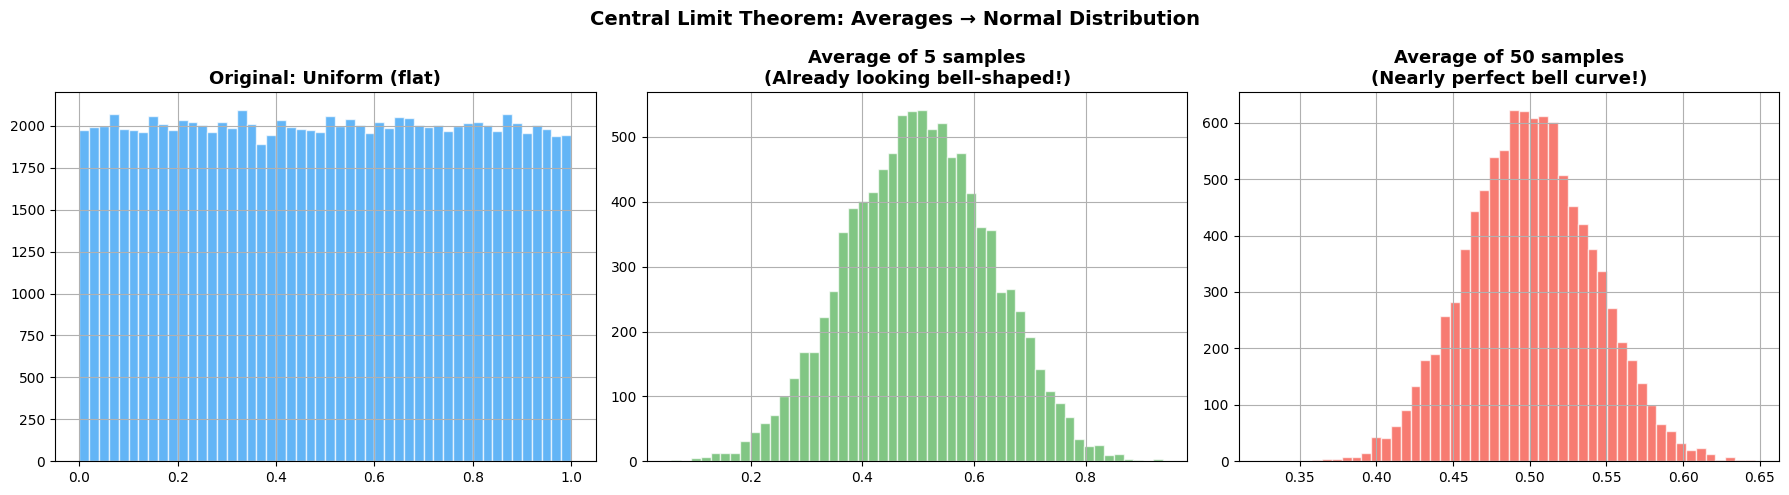

Even though original data is FLAT (uniform),
averages always converge to a BELL CURVE (normal).
This is why normal distribution shows up everywhere!


In [9]:
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

original = np.random.uniform(0, 1, 100000)
axes[0].hist(original, bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0].set_title('Original: Uniform (flat)', fontsize=13, fontweight='bold')

sample_means_5 = [np.mean(np.random.uniform(0, 1, 5)) for _ in range(10000)]
axes[1].hist(sample_means_5, bins=50, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[1].set_title('Average of 5 samples\n(Already looking bell-shaped!)', fontsize=13, fontweight='bold')

sample_means_50 = [np.mean(np.random.uniform(0, 1, 50)) for _ in range(10000)]
axes[2].hist(sample_means_50, bins=50, color='#F44336', alpha=0.7, edgecolor='white')
axes[2].set_title('Average of 50 samples\n(Nearly perfect bell curve!)', fontsize=13, fontweight='bold')

plt.suptitle('Central Limit Theorem: Averages → Normal Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Even though original data is FLAT (uniform),")
print("averages always converge to a BELL CURVE (normal).")
print("This is why normal distribution shows up everywhere!")

---
## 9. Summary

| Concept | What It Does | ML Application |
|---------|-------------|----------------|
| Mean/Median | Find center of data | Baseline predictions |
| Variance/Std | Measure spread | Model uncertainty |
| Normal Dist | Bell curve model | Assumption of many algorithms |
| Correlation | Measure relationships | Feature selection |
| Covariance Matrix | All pairwise relationships | PCA, Gaussian models |
| Bayes' Theorem | Update beliefs | Naive Bayes, spam filters |
| Central Limit Theorem | Averages → normal | Why normal is everywhere |

### Next: Applied Linear Algebra (`06_applied_linear_algebra.ipynb`)